# Part 2: Feature Engineering — From Prices to Predictive Signals

*"It's not about predicting the future. It's about building a systematic edge."*

---

The previous notebook established what our dataset looks like: fifty large-cap US stocks across five sectors, spanning 2010 to 2024, enriched with daily macro context from SPY, the VIX, Treasury yields, and the US dollar index. We saw how returns vary across sectors and years, and how tightly individual stocks co-move with the broad market.

This notebook asks a harder question: **can we extract signals from that data that actually predict future returns?** A raw daily return contains almost no information about tomorrow's return — if it did, everyone would already be trading it away. The practical question is whether carefully constructed *features* — momentum measures, volatility estimates, liquidity proxies, macro indicators — carry any incremental predictive information, even if small.

We proceed in three stages. We first examine a single stock, Apple, to build intuition: what does autocorrelation look like in daily returns, and why do we need more than just lagged returns? We then scale up to the full panel and build twelve features. Finally, we evaluate each feature's predictive content using the Information Coefficient and quintile portfolio analysis — two standard tools in quantitative research. The answer will motivate the approach taken in Part 3, where we combine all features into a machine-learning model.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import os

from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# ── Load the shared dataset ────────────────────────────────────────
DATA_DIR = 'data'

panel  = pd.read_parquet(f'{DATA_DIR}/ds4fe_panel.parquet')
market = pd.read_parquet(f'{DATA_DIR}/ds4fe_market.parquet')
info   = pd.read_csv(f'{DATA_DIR}/ds4fe_info.csv')

panel['date']  = pd.to_datetime(panel['date'])
market['date'] = pd.to_datetime(market['date'])

ticker_sector = info.set_index('ticker')['sector'].to_dict()
ticker_name   = info.set_index('ticker')['short_name'].to_dict()

sectors  = sorted(info['sector'].dropna().unique())
palette  = dict(zip(sectors, plt.cm.tab10.colors[:len(sectors)]))

print(f'panel  : {panel.shape[0]:>8,} rows  |  cols: {list(panel.columns)}')
print(f'market : {market.shape[0]:>8,} rows  |  cols: {list(market.columns)}')
print(f'info   : {len(info)} tickers  |  date range: {panel["date"].min().date()} to {panel["date"].max().date()}')

panel  :  187,247 rows  |  cols: ['date', 'ticker', 'close', 'volume', 'high', 'low', 'open', 'ret', 'sector', 'ret_fwd']
market :    3,771 rows  |  cols: ['date', 'spy_close', 'vix', 'yield_10y', 'yield_3m', 'usd_index', 'spy_volume', 'market_ret', 'yield_spread']
info   : 50 tickers  |  date range: 2010-01-05 to 2024-12-30


In [2]:
# ── Load data ─────────────────────────────────────────────────────
panel  = pd.read_parquet('data/ds4fe_panel.parquet')
market = pd.read_parquet('data/ds4fe_market.parquet')
info   = pd.read_csv('data/ds4fe_info.csv')

panel['date']  = pd.to_datetime(panel['date'])
market['date'] = pd.to_datetime(market['date'])

ticker_sector = dict(zip(info['ticker'], info['sector']))

# Merge macro context onto panel (used in feature engineering)
panel_m = panel.merge(
    market[['date', 'market_ret', 'vix', 'yield_spread', 'usd_index', 'spy_volume']],
    on='date', how='left'
)

print(f'Panel   : {panel.shape[0]:,} rows | {panel["ticker"].nunique()} tickers | {panel["date"].dt.year.min()}–{panel["date"].dt.year.max()}')
print(f'Market  : {market.shape[0]:,} rows | {list(market.columns)}')


Panel   : 187,247 rows | 50 tickers | 2010–2024
Market  : 3,771 rows | ['date', 'spy_close', 'vix', 'yield_10y', 'yield_3m', 'usd_index', 'spy_volume', 'market_ret', 'yield_spread']


## A Single Stock: Apple (AAPL)

Before working with fifty stocks at once, it is worth spending time with one. A close look at a single name builds the intuition we will need when interpreting results at the panel level.

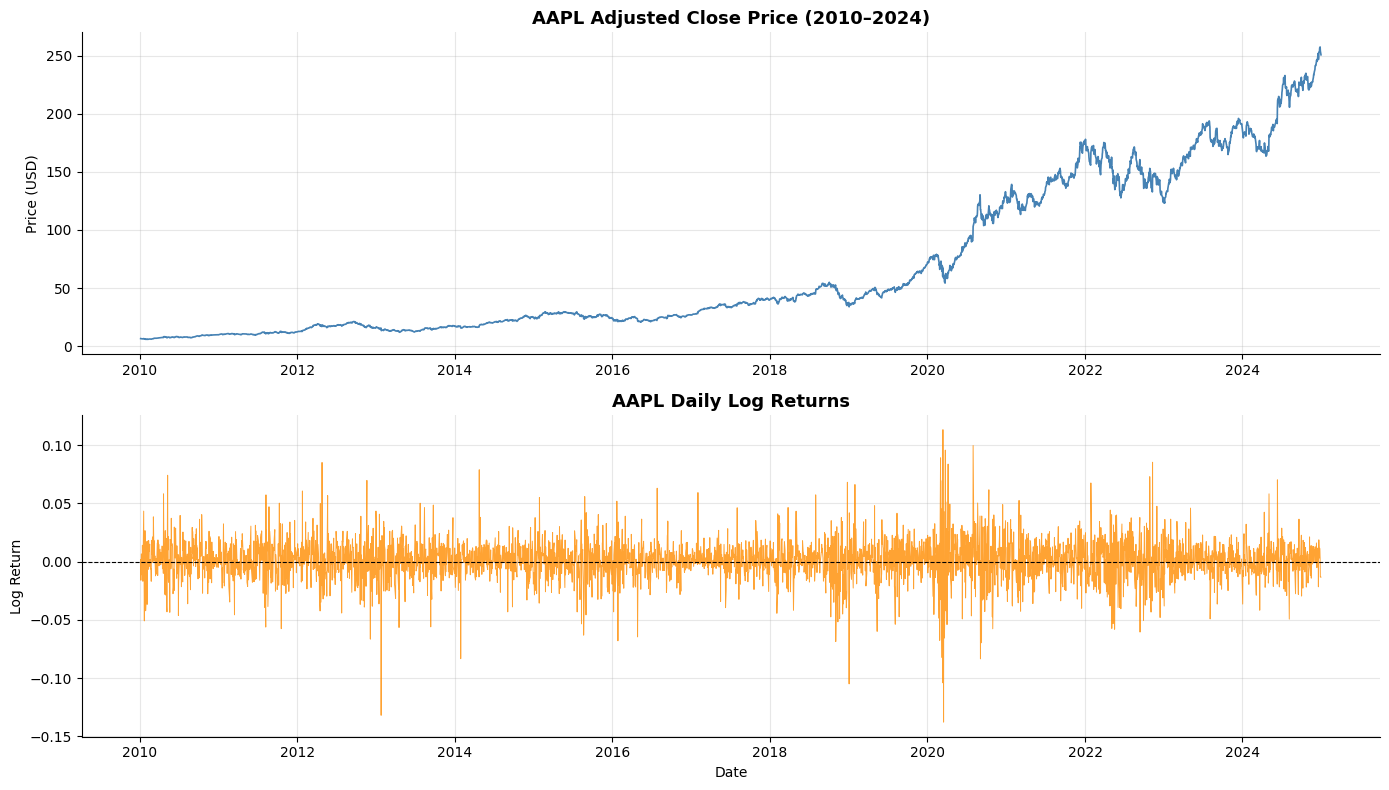

=== AAPL Daily Return Statistics ===
Mean (ann.)  : 24.50%   |   Vol (ann.) : 27.88%
Sharpe       : 0.88   |   Kurtosis   : 5.45  (normal=0)   |   Skew: -0.2353


In [3]:
# ── C1. Price vs. return ──────────────────────────────────────────
aapl = panel[panel['ticker'] == 'AAPL'].sort_values('date').copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(aapl['date'], aapl['close'], color='steelblue', linewidth=1.2)
axes[0].set_title('AAPL Adjusted Close Price (2010–2024)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)')

axes[1].plot(aapl['date'], aapl['ret'], color='darkorange', linewidth=0.7, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('AAPL Daily Log Returns', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Log Return')
axes[1].set_xlabel('Date')
plt.tight_layout()
plt.show()

r = aapl['ret']
print('=== AAPL Daily Return Statistics ===')
print(f'Mean (ann.)  : {r.mean()*252:.2%}   |   Vol (ann.) : {r.std()*np.sqrt(252):.2%}')
print(f'Sharpe       : {r.mean()/r.std()*np.sqrt(252):.2f}   |   Kurtosis   : {r.kurtosis():.2f}  (normal=0)   |   Skew: {r.skew():.4f}')

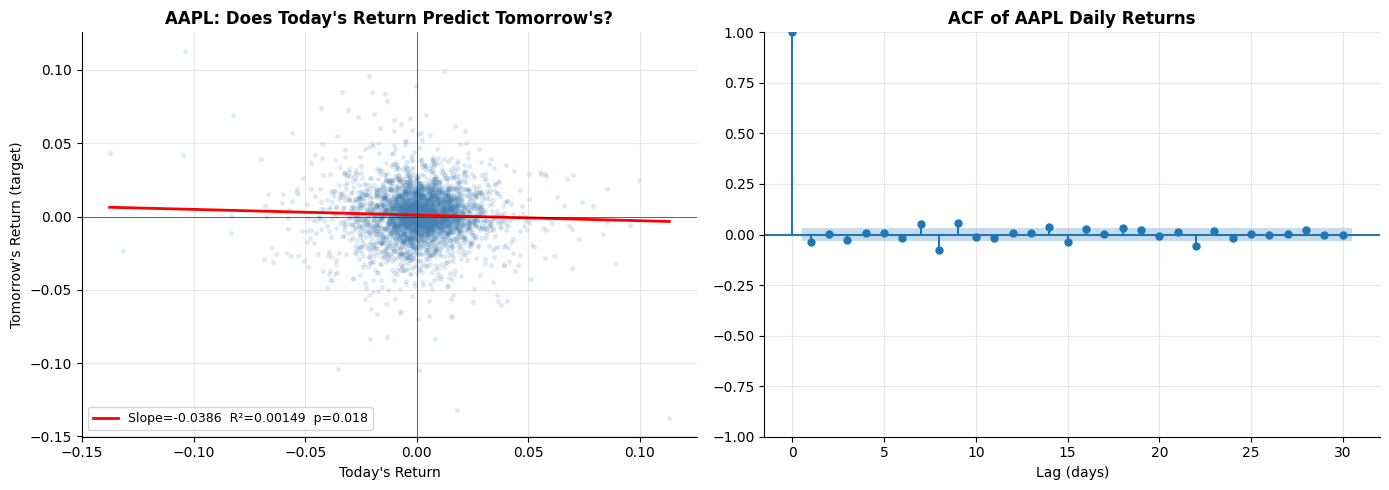

R² = 0.001492 — raw lagged return explains essentially nothing.
This motivates building richer features. A single lag is not enough.


In [4]:
# ── C2. Does yesterday predict tomorrow? ─────────────────────────
aapl_lag = pd.DataFrame({'x': aapl['ret'].values, 'y': aapl['ret_fwd'].values}).dropna()
slope, intercept, r_val, pval, _ = stats.linregress(aapl_lag['x'], aapl_lag['y'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(aapl_lag['x'], aapl_lag['y'], alpha=0.12, s=7, color='steelblue')
xl = np.linspace(aapl_lag['x'].min(), aapl_lag['x'].max(), 100)
axes[0].plot(xl, intercept + slope * xl, 'r-', linewidth=2,
             label=f'Slope={slope:.4f}  R²={r_val**2:.5f}  p={pval:.3f}')
axes[0].axhline(0, color='black', linewidth=0.4)
axes[0].axvline(0, color='black', linewidth=0.4)
axes[0].set_xlabel("Today's Return")
axes[0].set_ylabel("Tomorrow's Return (target)")
axes[0].set_title('AAPL: Does Today\'s Return Predict Tomorrow\'s?', fontweight='bold')
axes[0].legend(fontsize=9)

plot_acf(aapl['ret'].dropna(), lags=30, ax=axes[1], alpha=0.05)
axes[1].set_title('ACF of AAPL Daily Returns', fontweight='bold')
axes[1].set_xlabel('Lag (days)')

plt.tight_layout()
plt.show()
print(f'R² = {r_val**2:.6f} — raw lagged return explains essentially nothing.')
print('This motivates building richer features. A single lag is not enough.')

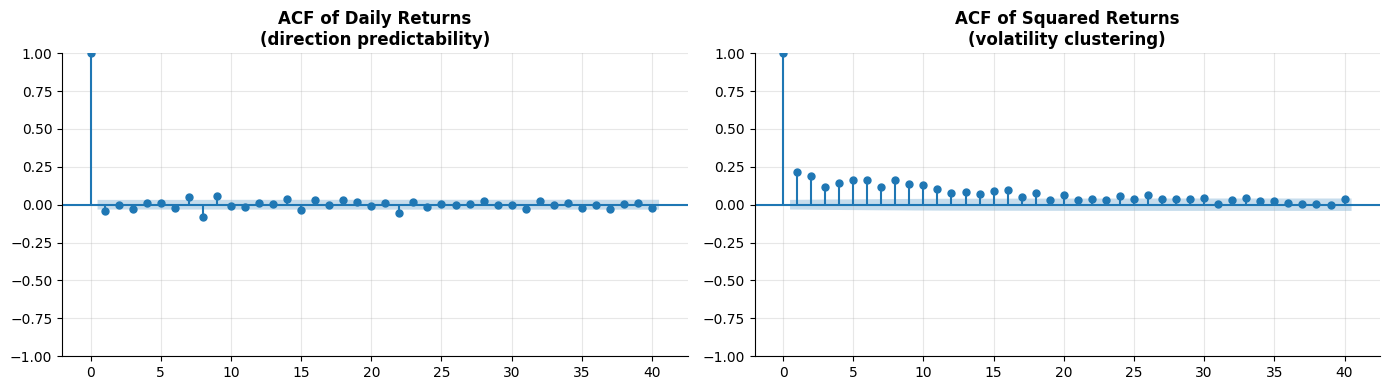

Returns:         autocorrelations mostly insignificant → direction is hard to predict
Squared returns: strong, persistent autocorrelation → volatility IS predictable
Implication: realized volatility is a useful feature — both as signal and risk measure.


In [5]:
# ── C3. Volatility clustering ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(aapl['ret'].dropna(),    lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF of Daily Returns\n(direction predictability)', fontweight='bold')
plot_acf(aapl['ret'].dropna()**2, lags=40, ax=axes[1], alpha=0.05)
axes[1].set_title('ACF of Squared Returns\n(volatility clustering)', fontweight='bold')
plt.tight_layout()
plt.show()

print('Returns:         autocorrelations mostly insignificant → direction is hard to predict')
print('Squared returns: strong, persistent autocorrelation → volatility IS predictable')
print('Implication: realized volatility is a useful feature — both as signal and risk measure.')

## From One Stock to Fifty

Working with a single stock gives us roughly 3,500 daily observations over fifteen years. Expanding to a panel of fifty stocks multiplies that to around 175,000 observations, which is far more useful for statistical inference. More importantly, it changes the nature of the prediction problem. Rather than asking whether Apple will go up tomorrow, we ask which of our fifty stocks will outperform the others. This is the cross-sectional prediction problem, and it is the setting in which most quantitative equity strategies operate.

## Feature Engineering

A feature — or factor, in the finance literature — is any variable derived from observable data that we believe may carry predictive information about future returns. We build four families here.

The momentum features are cumulative log returns over the past 1, 5, 21, and 63 trading days. The intuition is that stocks which have performed well recently may continue to do so over short to medium horizons, a finding that is well-documented in the empirical asset pricing literature. The volatility features are the annualized realized standard deviation over 21-day and 63-day windows, which capture the risk regime a stock is currently in. The volume and liquidity features include a volume ratio (today's volume relative to its 20-day average) and the Amihud illiquidity measure, which divides the absolute return by dollar volume and captures how much price impact a given level of trading tends to produce. Finally, the macro features bring in the lagged SPY return, VIX level, yield spread, and dollar index.

One rule applies without exception: every feature at date $t$ must be constructed using only data available at the close of day $t$. The prediction target is always the return on day $t+1$. Violating this — even subtly — produces optimistic results that will not hold up out of sample.

In [6]:
def build_features(panel_df, market_df):
    ret_w   = panel_df.pivot(index='date', columns='ticker', values='ret')
    vol_w   = panel_df.pivot(index='date', columns='ticker', values='volume')
    close_w = panel_df.pivot(index='date', columns='ticker', values='close')

    feats = {}
    # Momentum — shift(1): most recent known return is yesterday's
    feats['mom_1d']  = ret_w.shift(1)
    feats['mom_5d']  = ret_w.shift(1).rolling(5).sum()
    feats['mom_21d'] = ret_w.shift(1).rolling(21).sum()
    feats['mom_63d'] = ret_w.shift(1).rolling(63).sum()
    # Volatility
    feats['vol_21d'] = ret_w.shift(1).rolling(21).std() * np.sqrt(252)
    feats['vol_63d'] = ret_w.shift(1).rolling(63).std() * np.sqrt(252)
    # Volume / Liquidity
    feats['volume_ratio'] = vol_w.shift(1) / (vol_w.shift(1).rolling(20).mean() + 1e-10)
    dollar_vol = vol_w * close_w
    feats['illiq_21d'] = (ret_w.abs() / (dollar_vol + 1e-10)).shift(1).rolling(21).mean() * 1e6
    # Target
    feats['ret_fwd'] = ret_w

    long_dfs = []
    for name, w in feats.items():
        s = w.stack().rename(name)
        s.index.names = ['date', 'ticker']
        long_dfs.append(s)
    result = pd.concat(long_dfs, axis=1).reset_index()

    # Merge macro features (lag by 1 day)
    macro_cols = ['date', 'market_ret', 'vix', 'yield_spread', 'usd_index', 'spy_volume']
    result = result.merge(market_df[macro_cols], on='date', how='left')
    for col in ['market_ret', 'vix', 'yield_spread', 'usd_index', 'spy_volume']:
        result[col] = result.groupby('ticker')[col].shift(1)

    result['sector'] = result['ticker'].map(ticker_sector)
    result = result.dropna(subset=['mom_1d', 'ret_fwd']).reset_index(drop=True)
    return result


print('Building features...')
feat = build_features(panel_m, market)

FEATURE_COLS = ['mom_1d', 'mom_5d', 'mom_21d', 'mom_63d',
                'vol_21d', 'vol_63d', 'volume_ratio', 'illiq_21d',
                'market_ret', 'vix', 'yield_spread', 'usd_index']

print(f'Feature panel: {feat.shape[0]:,} rows')
feat[['date', 'ticker', 'sector'] + FEATURE_COLS[:4] + ['ret_fwd']].head()

Building features...


Feature panel: 187,197 rows


,date,ticker,sector,mom_1d,mom_5d,mom_21d,mom_63d,ret_fwd
0,2010-01-06,AAPL,Technology,0.001728,NaN,NaN,NaN,-0.016034
1,2010-01-06,ABT,Healthcare,-0.008112,NaN,NaN,NaN,0.005538
2,2010-01-06,ADBE,Technology,0.016313,NaN,NaN,NaN,-0.002124
3,2010-01-06,AMD,Technology,0.001030,NaN,NaN,NaN,-0.014523
4,2010-01-06,AMGN,Healthcare,-0.008700,NaN,NaN,NaN,-0.007544


In [7]:
feat[FEATURE_COLS + ['ret_fwd']].describe().round(5)

,mom_1d,mom_5d,mom_21d,mom_63d,vol_21d,vol_63d,volume_ratio,illiq_21d,market_ret,vix,yield_spread,usd_index,ret_fwd
count,187197.00000,186997.00000,186197.00000,184097.00000,186197.00000,184097.00000,186247.00000,186197.00000,187097.00000,187097.00000,187097.00000,187097.00000,187197.00000
mean,0.00055,0.00274,0.01174,0.03549,0.25011,0.25862,1.00673,0.00003,0.00051,18.34821,1.28989,92.28912,0.00055
std,0.01810,0.03930,0.07866,0.13128,0.14305,0.12626,0.43077,0.00005,0.01077,6.96165,1.22906,9.34551,0.01810
min,-0.30639,-0.62105,-1.26396,-1.24124,0.03692,0.06306,0.00000,0.00000,-0.11589,9.14000,-1.70400,72.93000,-0.30639
25%,-0.00744,-0.01599,-0.02848,-0.03508,0.16050,0.17826,0.75517,0.00001,-0.00371,13.58000,0.50900,82.27000,-0.00745
50%,0.00064,0.00380,0.01516,0.04123,0.21489,0.22850,0.91795,0.00002,0.00068,16.54000,1.50100,94.55000,0.00063
75%,0.00887,0.02292,0.05511,0.11118,0.29556,0.29886,1.13939,0.00003,0.00577,21.14000,2.11600,98.79000,0.00887
max,0.42062,0.61400,0.58505,0.76926,2.22261,1.46282,11.33123,0.00187,0.08673,82.69000,3.83400,114.11000,0.42062


In [8]:
# Cross-sectional ranking
for col in FEATURE_COLS:
    feat[col + '_rank'] = feat.groupby('date')[col].rank(pct=True, na_option='keep')

RANK_COLS = [c + '_rank' for c in FEATURE_COLS]
print('Cross-sectional percentile ranks added.')
feat[['date', 'ticker'] + RANK_COLS[:4]].head()

Cross-sectional percentile ranks added.


,date,ticker,mom_1d_rank,mom_5d_rank,mom_21d_rank,mom_63d_rank
0,2010-01-06,AAPL,0.437500,NaN,NaN,NaN
1,2010-01-06,ABT,0.187500,NaN,NaN,NaN
2,2010-01-06,ADBE,0.770833,NaN,NaN,NaN
3,2010-01-06,AMD,0.395833,NaN,NaN,NaN
4,2010-01-06,AMGN,0.166667,NaN,NaN,NaN


## Does Any Feature Predict Returns?

We use two complementary tools to assess predictability. The first is the **information coefficient** (IC), defined as the Spearman rank correlation between a feature's cross-sectional rank on day $t$ and the actual return on day $t+1$, computed each day and then summarized over time. An IC consistently different from zero — and the IC information ratio (mean IC divided by its standard deviation) — tells us whether the signal is both economically meaningful and stable. The second tool is quintile analysis: we sort stocks into five groups by feature value each day and look at the average next-day return in each group. A monotone pattern from the bottom quintile to the top is evidence that the feature carries directional information.

In [9]:
print('Computing daily IC (may take ~30s)...')

ic_records = []
for date, group in feat.groupby('date'):
    if len(group) < 10:
        continue
    row = {'date': date}
    for col in FEATURE_COLS:
        valid = group[[col, 'ret_fwd']].dropna()
        if len(valid) >= 10:
            c, _ = stats.spearmanr(valid[col], valid['ret_fwd'])
            row[col] = c
        else:
            row[col] = np.nan
    ic_records.append(row)

ic_df = pd.DataFrame(ic_records).set_index('date')

ic_summary = pd.DataFrame({
    'Mean IC': ic_df.mean(),
    'Std IC' : ic_df.std(),
    'IC IR'  : ic_df.mean() / ic_df.std(),
    '% IC>0' : (ic_df > 0).mean() * 100,
    't-stat' : ic_df.mean() / (ic_df.std() / np.sqrt(len(ic_df))),
}).round(4).sort_values('IC IR', key=abs, ascending=False)

print('\n=== IC Summary (sorted by |IC IR|) ===')
ic_summary

Computing daily IC (may take ~30s)...



=== IC Summary (sorted by |IC IR|) ===


,Mean IC,Std IC,IC IR,% IC>0,t-stat
mom_1d,-0.0122,0.2419,-0.0506,47.8653,-3.1048
volume_ratio,0.0065,0.1755,0.0368,51.1801,2.2590
mom_5d,-0.0088,0.2479,-0.0357,48.8465,-2.1893
mom_63d,0.0052,0.2642,0.0197,50.8088,1.2102
vol_21d,-0.0038,0.2777,-0.0138,49.2442,-0.8496
vol_63d,-0.0030,0.2939,-0.0101,49.7216,-0.6218
illiq_21d,0.0014,0.2064,0.0069,50.6497,0.4217
mom_21d,-0.0009,0.2509,-0.0037,50.7558,-0.2263
market_ret,NaN,NaN,NaN,0.0000,NaN
vix,NaN,NaN,NaN,0.0000,NaN


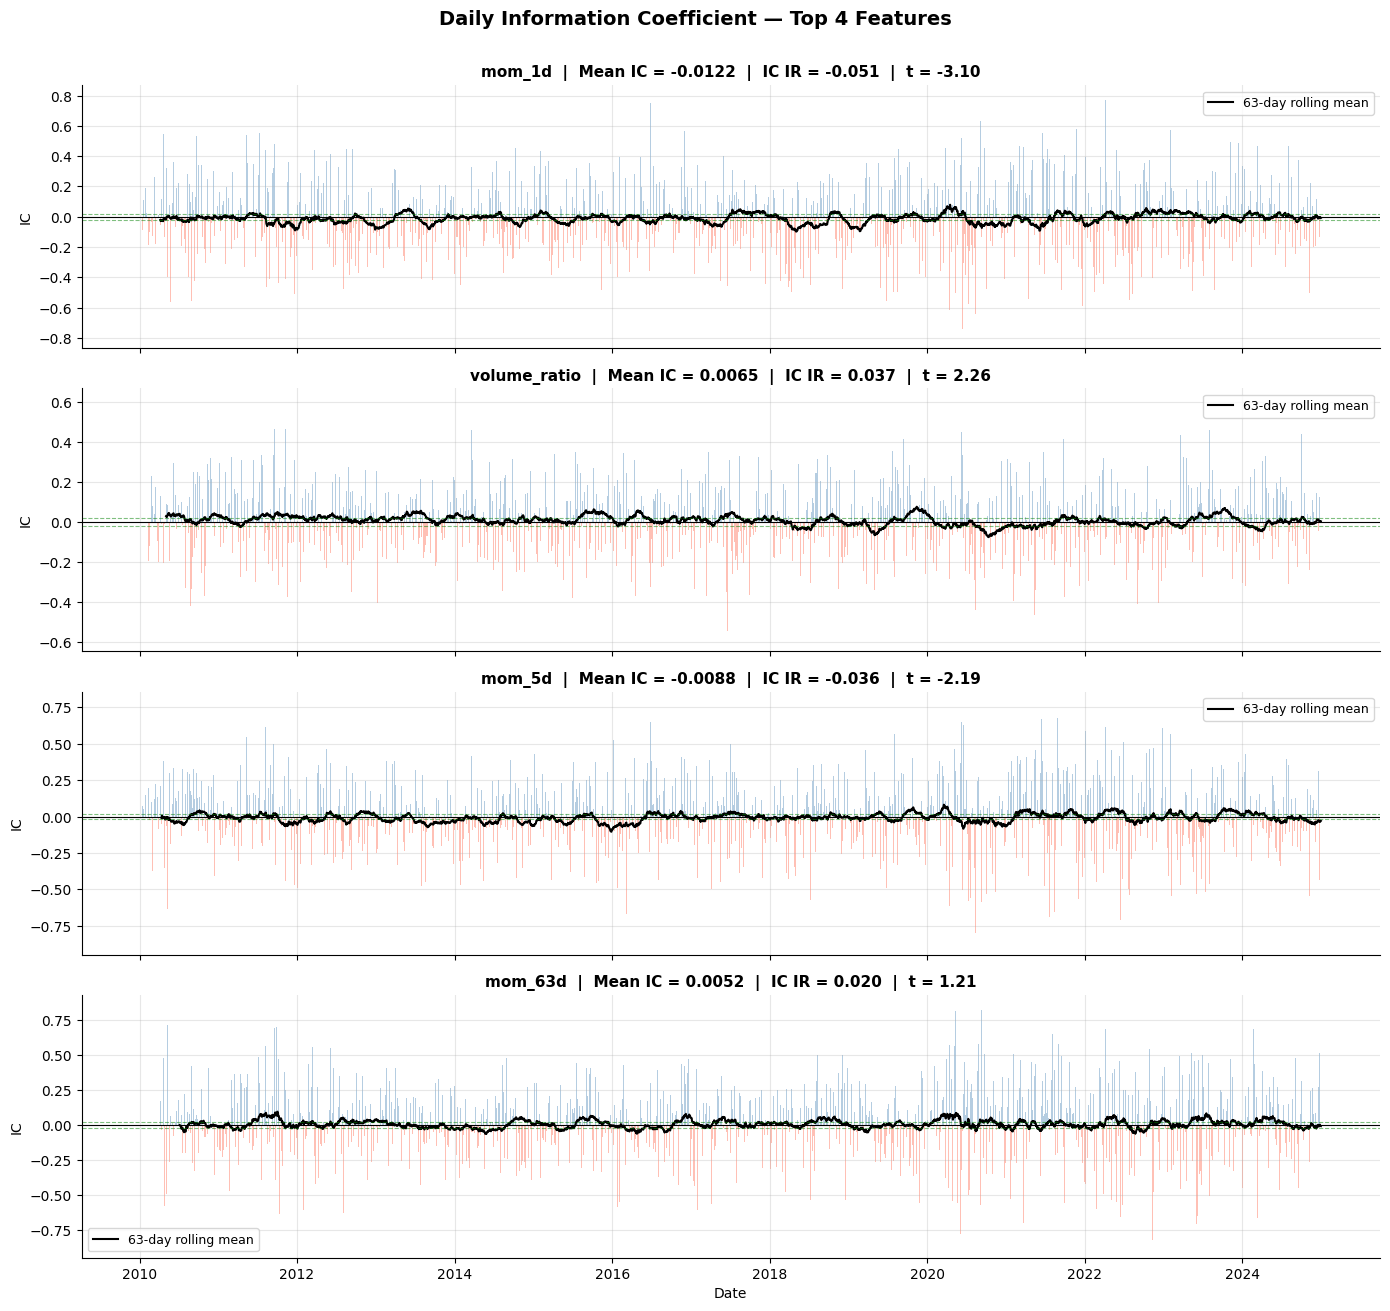

In [10]:
# IC over time — top 4 features
top4 = ic_summary.index[:4].tolist()

fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=True)
for i, fname in enumerate(top4):
    s = ic_df[fname]
    rm = s.rolling(63).mean()
    axes[i].bar(ic_df.index, s, color=np.where(s > 0, 'steelblue', 'tomato'), alpha=0.4, width=1)
    axes[i].plot(ic_df.index, rm, 'k-', linewidth=1.5, label='63-day rolling mean')
    axes[i].axhline(0, color='black', linewidth=0.8)
    axes[i].axhline(0.02,  color='green', linewidth=0.8, linestyle='--', alpha=0.5)
    axes[i].axhline(-0.02, color='green', linewidth=0.8, linestyle='--', alpha=0.5)
    axes[i].set_title(
        f'{fname}  |  Mean IC = {ic_summary.loc[fname,"Mean IC"]:.4f}  '
        f'|  IC IR = {ic_summary.loc[fname,"IC IR"]:.3f}  '
        f'|  t = {ic_summary.loc[fname,"t-stat"]:.2f}',
        fontweight='bold', fontsize=11)
    axes[i].set_ylabel('IC')
    axes[i].legend(fontsize=9)
axes[-1].set_xlabel('Date')
plt.suptitle('Daily Information Coefficient — Top 4 Features', fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

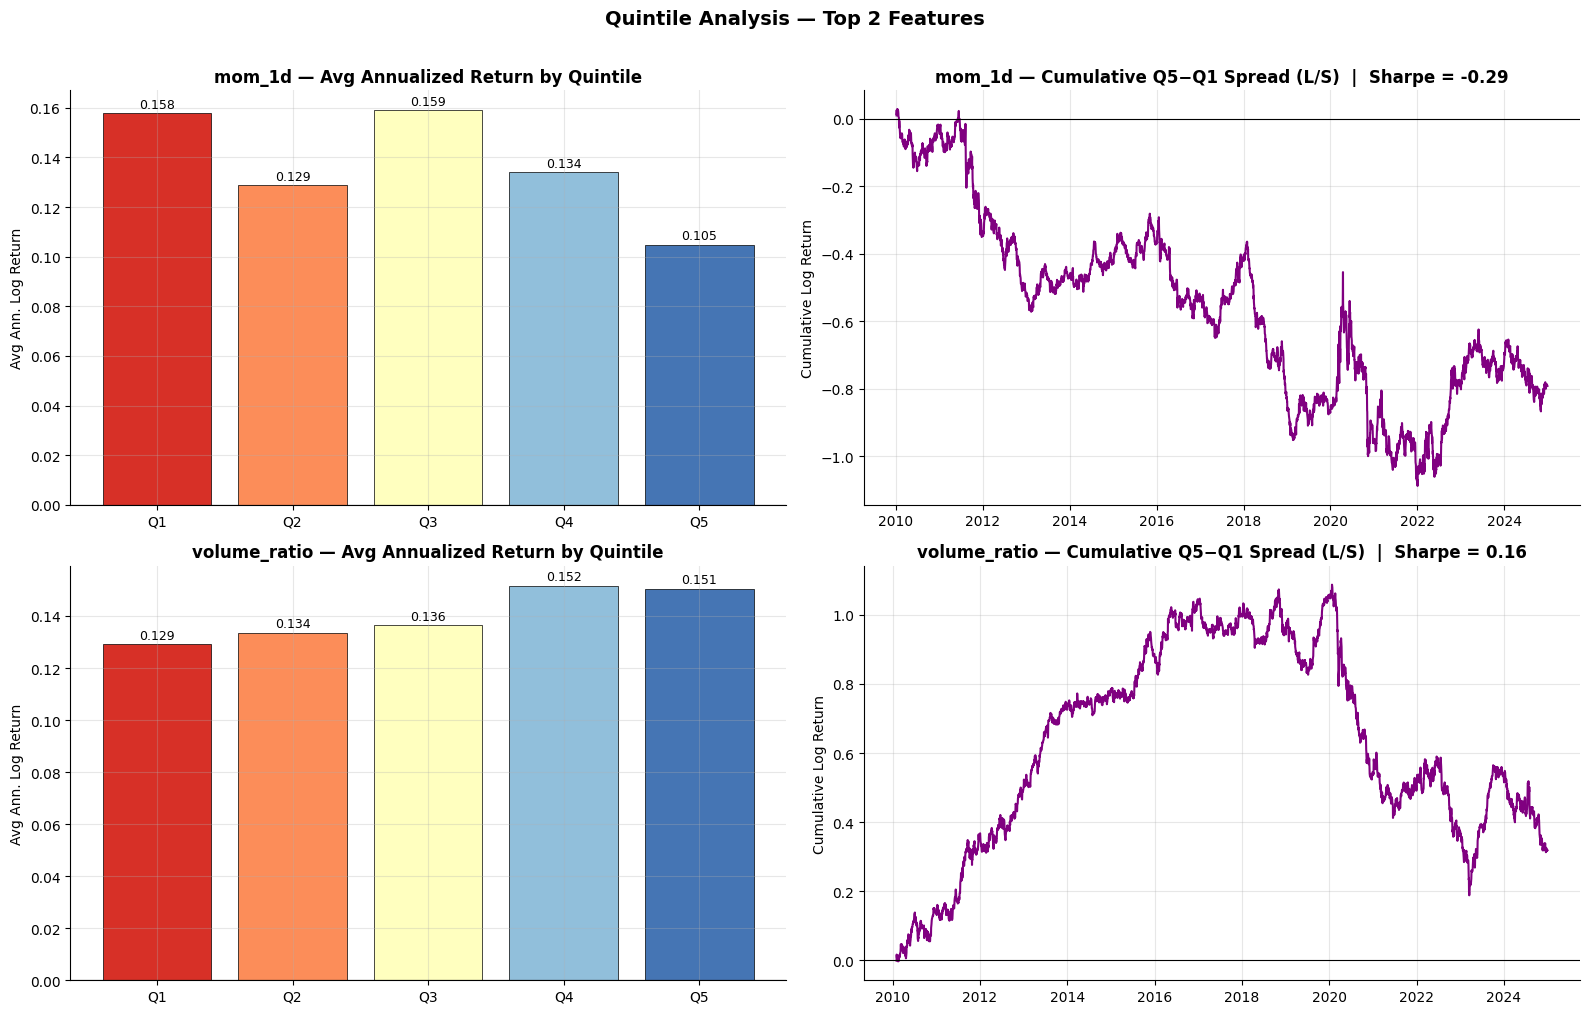

In [11]:
def quintile_analysis(df, feature, target='ret_fwd', n=5):
    d = df[['date', 'ticker', feature, target]].dropna().copy()
    d['q'] = d.groupby('date')[feature].transform(
        lambda x: pd.qcut(x, n, labels=False, duplicates='drop') + 1)
    d = d.dropna(subset=['q'])
    q_rets = d.groupby(['date', 'q'])[target].mean().unstack('q')
    q_rets.columns = [f'Q{int(c)}' for c in q_rets.columns]
    q_rets['spread'] = q_rets.get('Q5', 0) - q_rets.get('Q1', 0)
    return q_rets

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors_q = ['#d73027', '#fc8d59', '#ffffbf', '#91bfdb', '#4575b4']

for row_idx, fname in enumerate(top4[:2]):
    q = quintile_analysis(feat, fname)
    qc = [c for c in q.columns if c.startswith('Q')]
    qm = q[qc].mean() * 252

    bars = axes[row_idx][0].bar(qm.index, qm.values, color=colors_q[:len(qm)],
                                 edgecolor='black', linewidth=0.5)
    axes[row_idx][0].axhline(0, color='black', linewidth=0.8)
    axes[row_idx][0].set_title(f'{fname} — Avg Annualized Return by Quintile', fontweight='bold')
    axes[row_idx][0].set_ylabel('Avg Ann. Log Return')
    for bar, val in zip(bars, qm.values):
        axes[row_idx][0].text(bar.get_x() + bar.get_width()/2,
                               bar.get_height() + 0.001,
                               f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    spread_sharpe = q['spread'].mean() / q['spread'].std() * np.sqrt(252)
    axes[row_idx][1].plot(q.index, q['spread'].cumsum(), color='purple', linewidth=1.5)
    axes[row_idx][1].axhline(0, color='black', linewidth=0.8)
    axes[row_idx][1].set_title(
        f'{fname} — Cumulative Q5−Q1 Spread (L/S)  |  Sharpe = {spread_sharpe:.2f}',
        fontweight='bold')
    axes[row_idx][1].set_ylabel('Cumulative Log Return')

plt.suptitle('Quintile Analysis — Top 2 Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

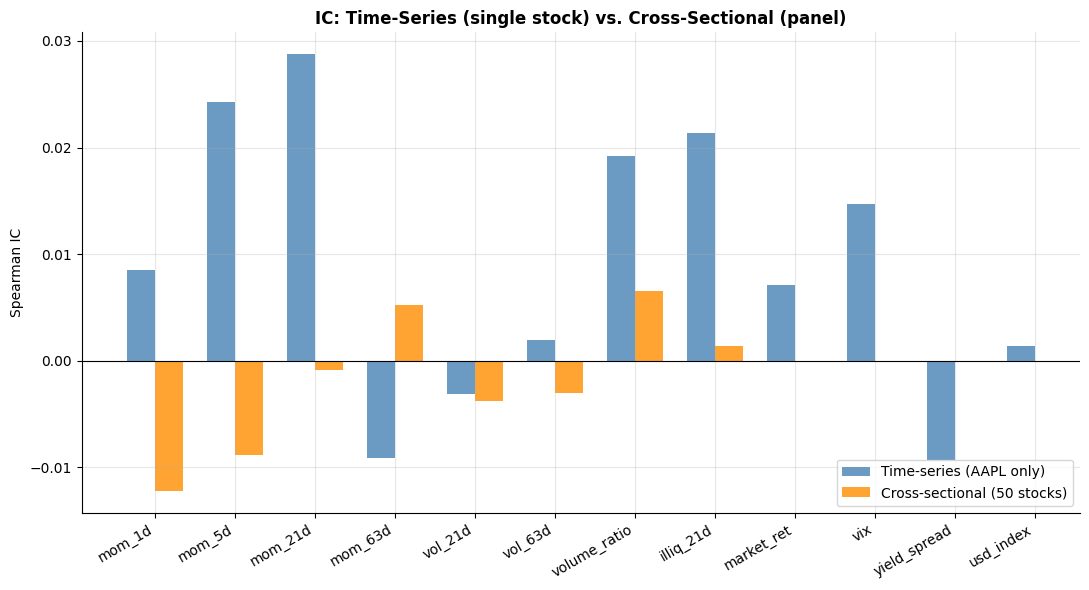

Key insight:
  Time-series IC (AAPL only): noisy, often near zero — too few observations
  Cross-sectional IC (panel): more stable — N is 50x larger per period
  → Cross-sectional is the standard approach in quantitative investing


In [12]:
# ── F3. Time-series vs. cross-sectional side-by-side ─────────────
aapl_feat = feat[feat['ticker'] == 'AAPL'].sort_values('date')
ts_rows = []
for f in FEATURE_COLS:
    valid = aapl_feat[[f, 'ret_fwd']].dropna()
    if len(valid) > 50:
        c, pv = stats.spearmanr(valid[f], valid['ret_fwd'])
        ts_rows.append({'feature': f, 'IC': c, 'p-value': pv})
ts_ic = pd.DataFrame(ts_rows).set_index('feature')

comparison = ts_ic[['IC']].rename(columns={'IC': 'TS: AAPL only'})\
    .join(ic_summary[['Mean IC']].rename(columns={'Mean IC': 'XS: all 50 stocks'}))

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(comparison))
w = 0.35
ax.bar(x - w/2, comparison['TS: AAPL only'],     width=w, label='Time-series (AAPL only)', color='steelblue', alpha=0.8)
ax.bar(x + w/2, comparison['XS: all 50 stocks'], width=w, label='Cross-sectional (50 stocks)', color='darkorange', alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=30, ha='right')
ax.set_title('IC: Time-Series (single stock) vs. Cross-Sectional (panel)', fontsize=12, fontweight='bold')
ax.set_ylabel('Spearman IC')
ax.legend()
plt.tight_layout()
plt.show()

print('Key insight:')
print('  Time-series IC (AAPL only): noisy, often near zero — too few observations')
print('  Cross-sectional IC (panel): more stable — N is 50x larger per period')
print('  → Cross-sectional is the standard approach in quantitative investing')

## Summary

The feature set constructed in this notebook covers twelve variables drawn from three sources: the stock's own price history (momentum at four horizons, realized volatility at two), its volume and liquidity behavior (volume ratio and Amihud illiquidity), and the macro environment (lagged SPY return, VIX, yield spread, and the dollar index). These are computed for all fifty stocks in the panel and stored in long format, one row per stock per day, with the next-day return as the target.

A few things are worth keeping in mind as we move forward. Return direction is difficult to predict at daily frequency — the autocorrelation structure in returns is weak, and individual stock noise is substantial. Volatility, by contrast, is highly persistent, which is why volatility-related features tend to show more stable IC than momentum. The cross-sectional setting has a material advantage over the single-stock setting: by working with fifty stocks simultaneously, we get far more observations per unit of time, and the relative ranking of stocks on a given feature is more informative than the raw time-series value for any one name.

Look-ahead bias is the most common failure mode in this kind of analysis. A feature that uses information not yet available at the time a prediction would need to be made will always look better than it really is. Every feature here is shifted forward by at least one day to guard against this.

In Part 2, we take these features and fit predictive models — linear regression, ridge, and random forest — using a walk-forward evaluation that respects the time ordering of the data. We also ask whether the model's predictions, however noisy, can be translated into a long-short portfolio with positive returns.

**Exercise.** Add a 252-day momentum feature (`mom_252d`). Does it have a higher or lower IC than `mom_63d`, and does the sign agree with what you would expect from the academic literature on momentum?

**Exercise.** Demean each feature within its sector before computing the IC. Does this sector-neutral adjustment change which features appear most predictive?

**Exercise.** The Amihud illiquidity measure (`illiq_21d`) is higher for stocks where a given dollar of trading moves the price more. Based on the IC and quintile results, does higher illiquidity predict higher or lower next-day returns? Propose an economic explanation.

**Exercise.** Compare the IC for `market_ret` (the lagged SPY return) with `mom_1d` (the stock's own lagged return). What does the difference in sign or magnitude tell you about how much of short-term momentum is market-wide versus stock-specific?

**Exercise.** *(Challenge.)* Compute a 63-day rolling IC for the VIX feature and plot it alongside the VIX level itself. Does the VIX appear to be a more reliable predictor during high-volatility regimes?